In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahsan81/hotel-reservations-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 480k/480k [00:00<00:00, 28.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ahsan81/hotel-reservations-classification-dataset/versions/1


In [2]:
# import neccesary library

# data
import pandas as pd
import numpy as np

# viusalization
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import plot
from wordcloud import WordCloud
from PIL import Image

In [3]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/ahsan81/hotel-reservations-classification-dataset/versions/1/Hotel Reservations.csv')

In [4]:
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


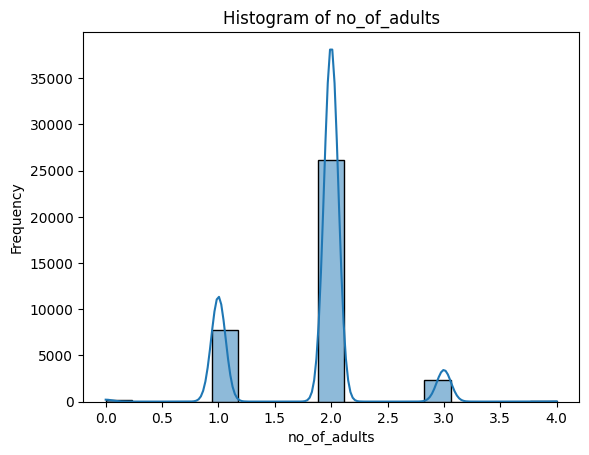

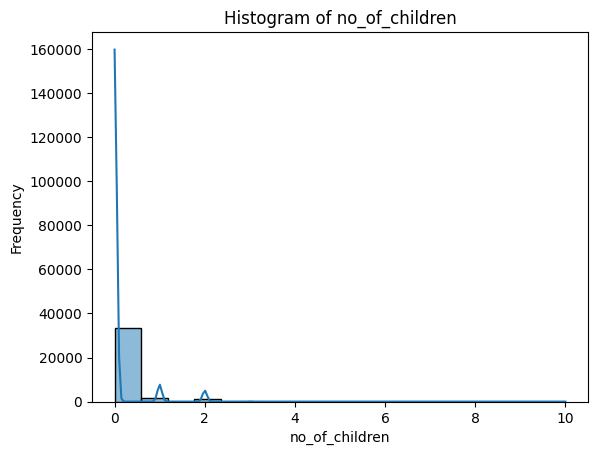

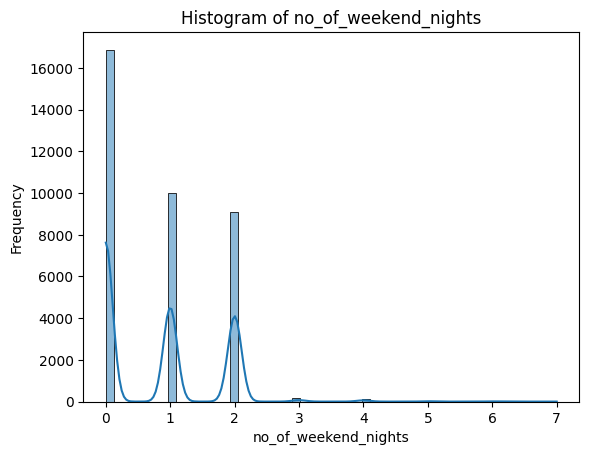

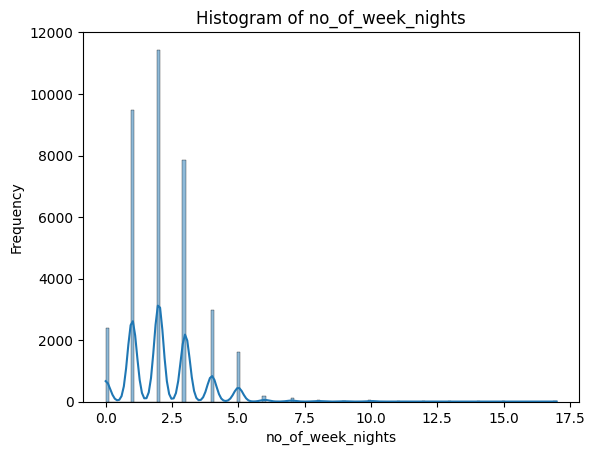

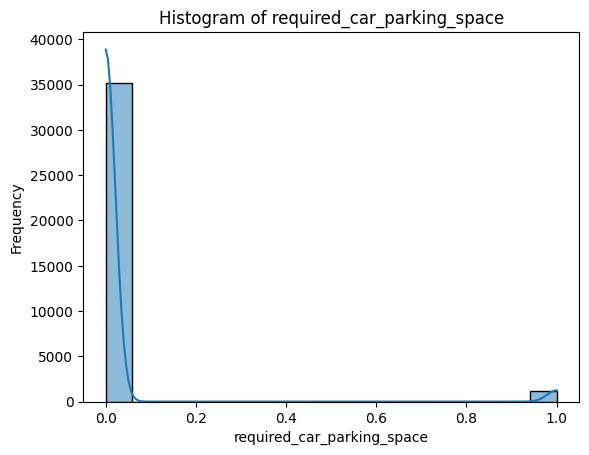

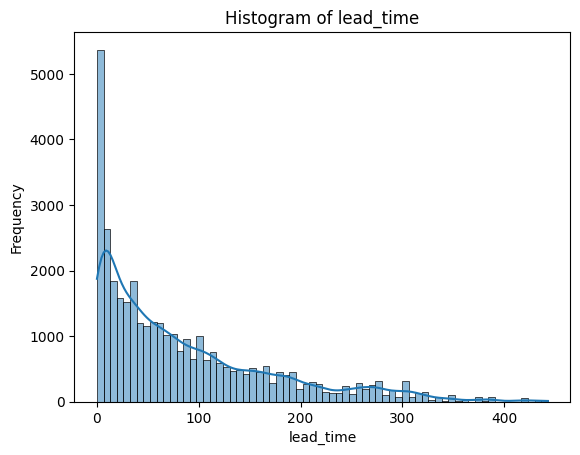

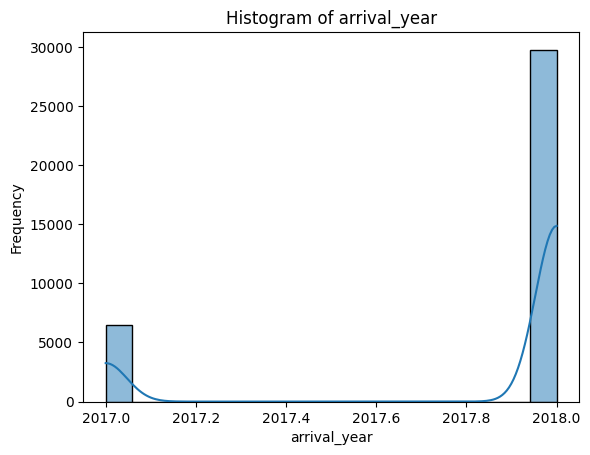

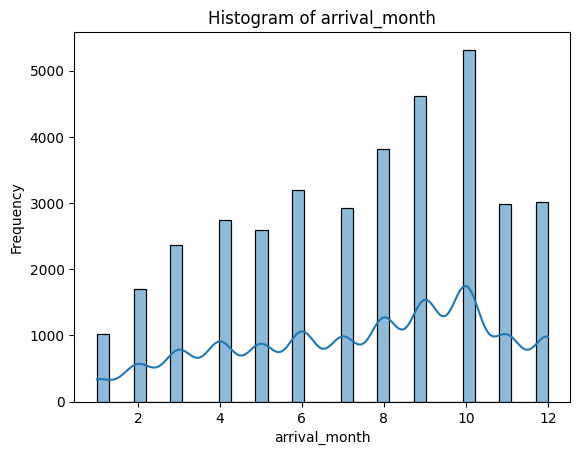

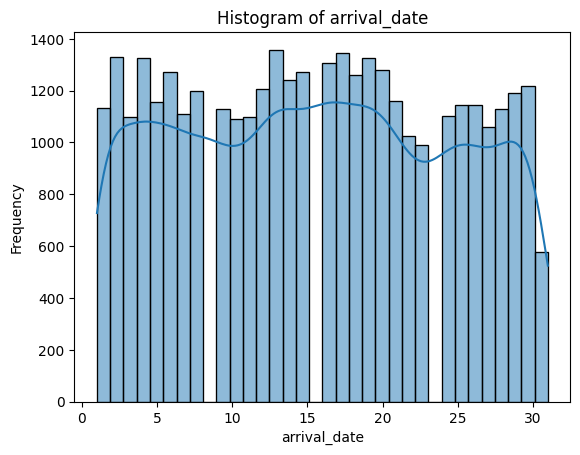

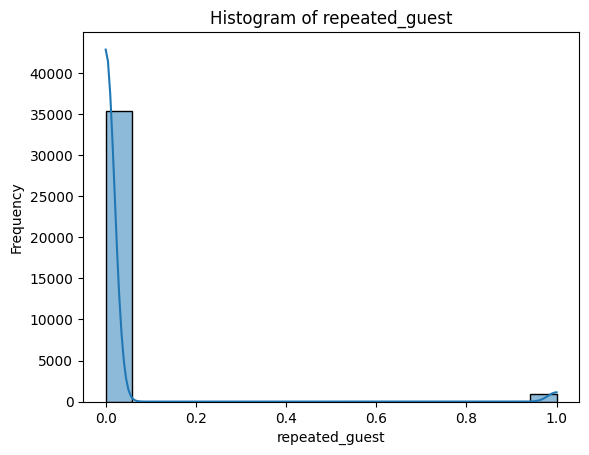

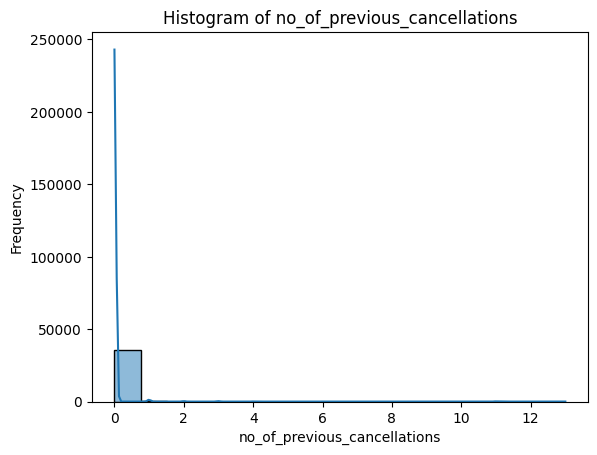

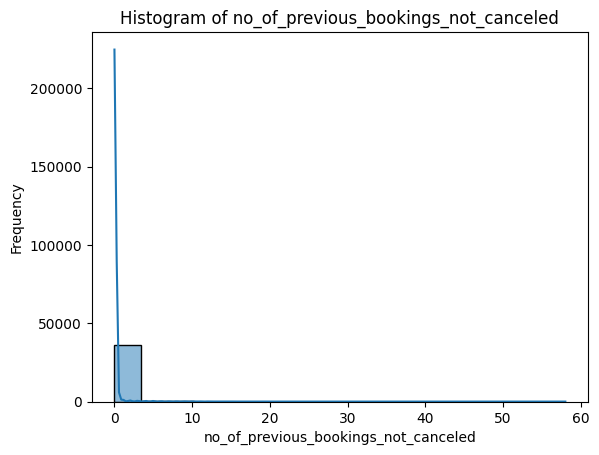

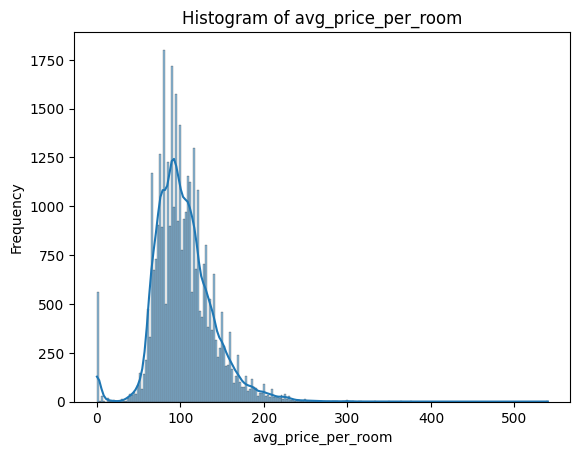

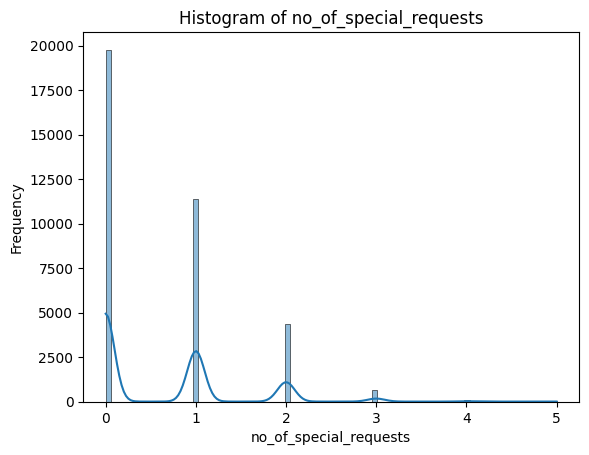

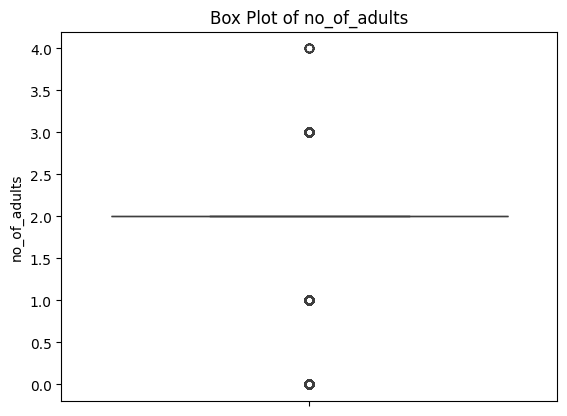

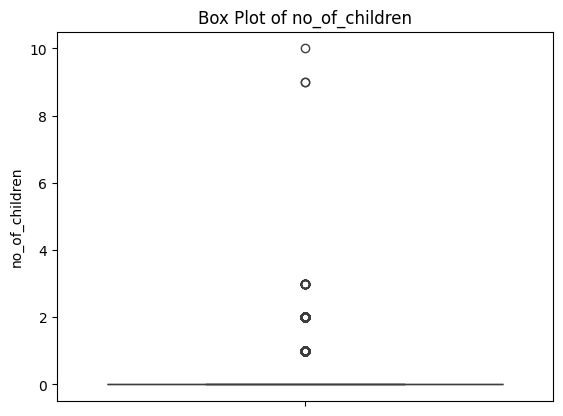

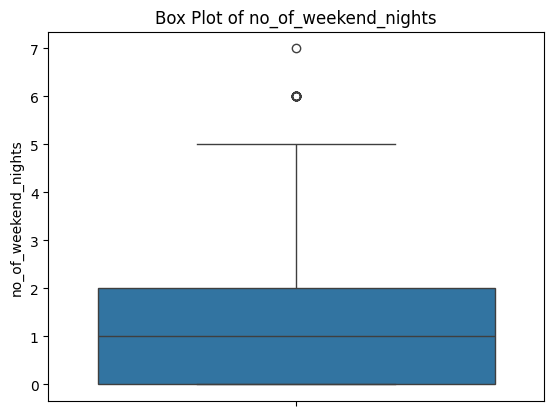

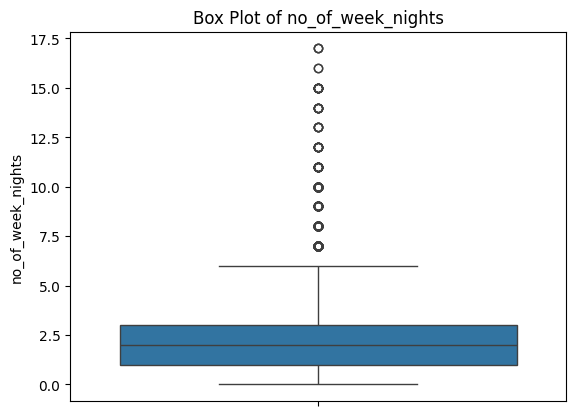

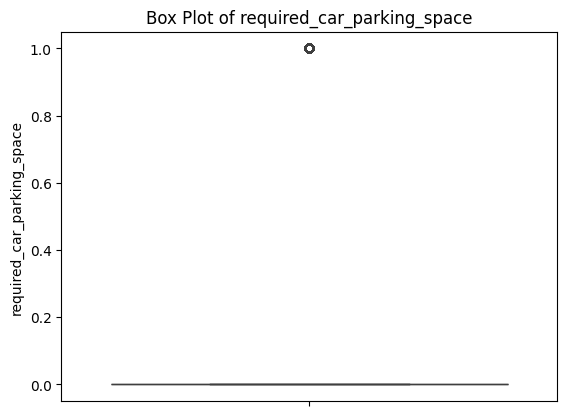

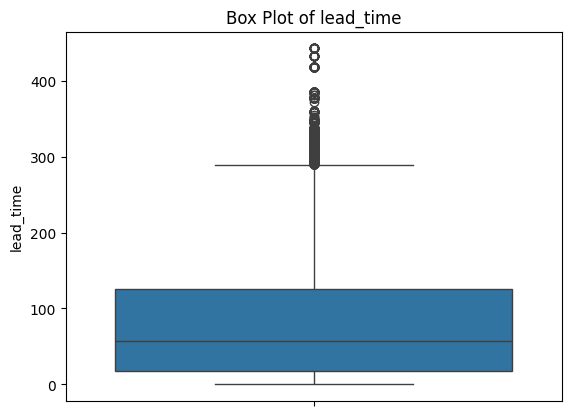

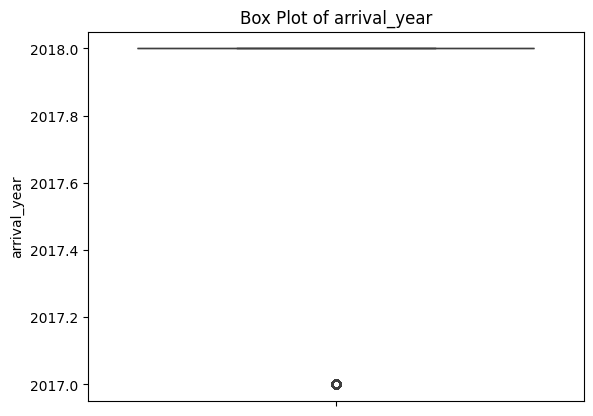

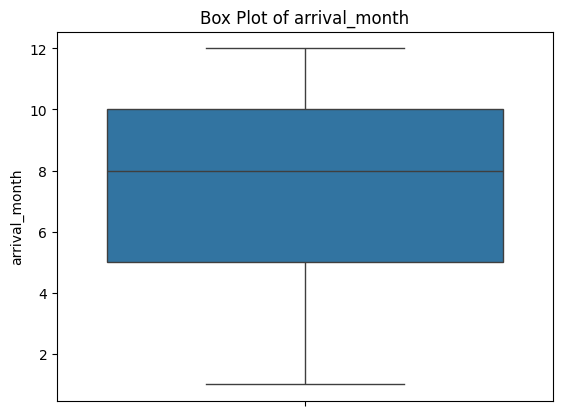

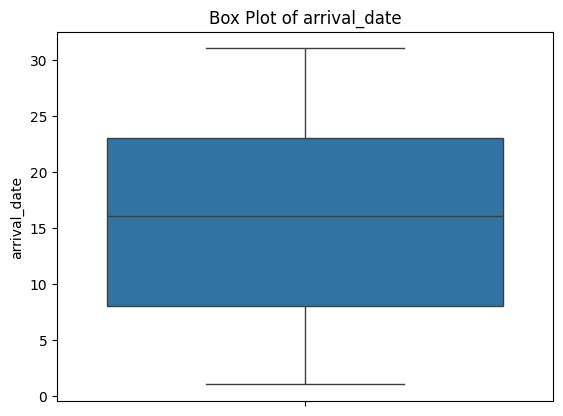

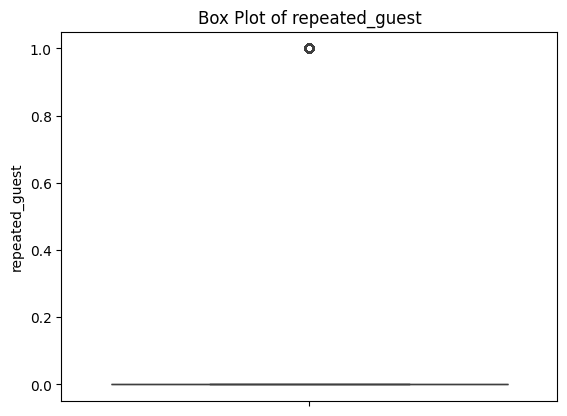

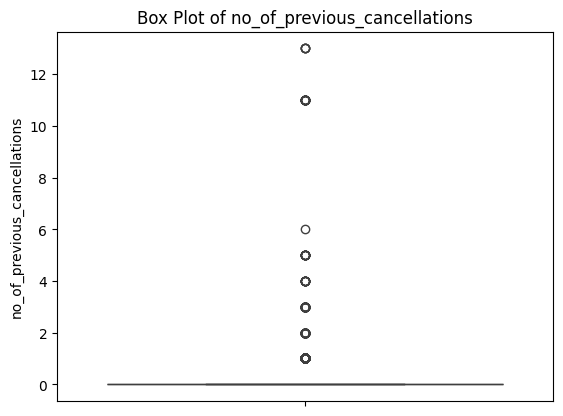

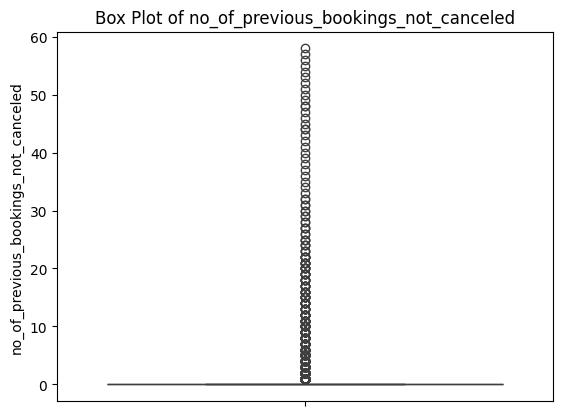

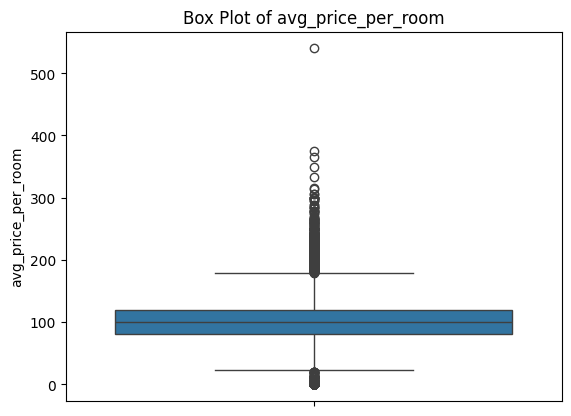

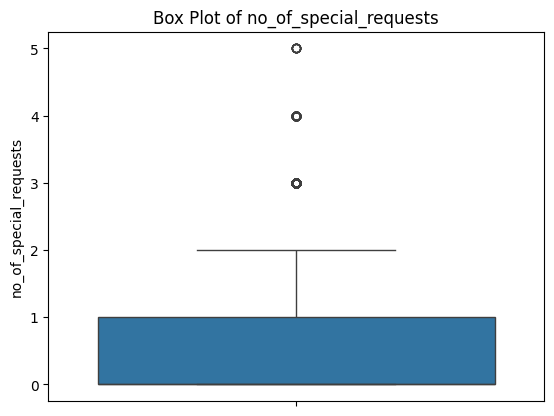

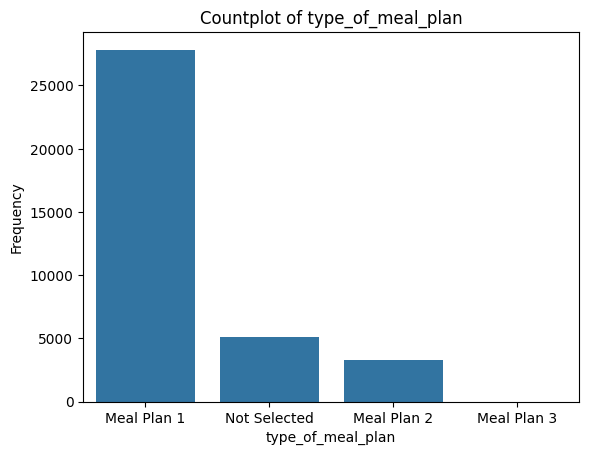

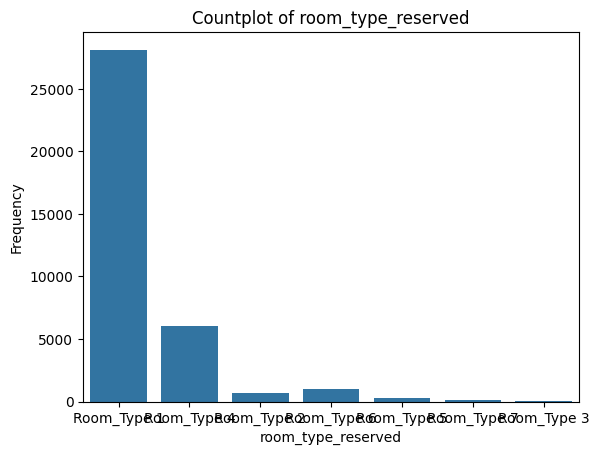

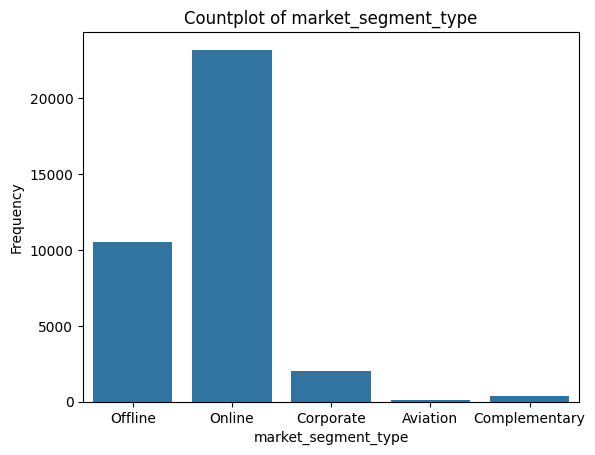

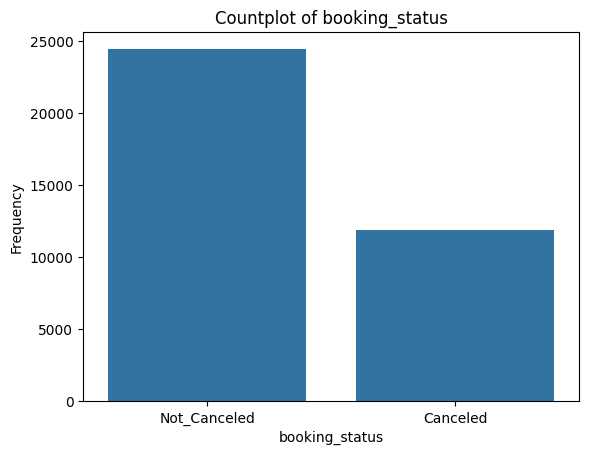

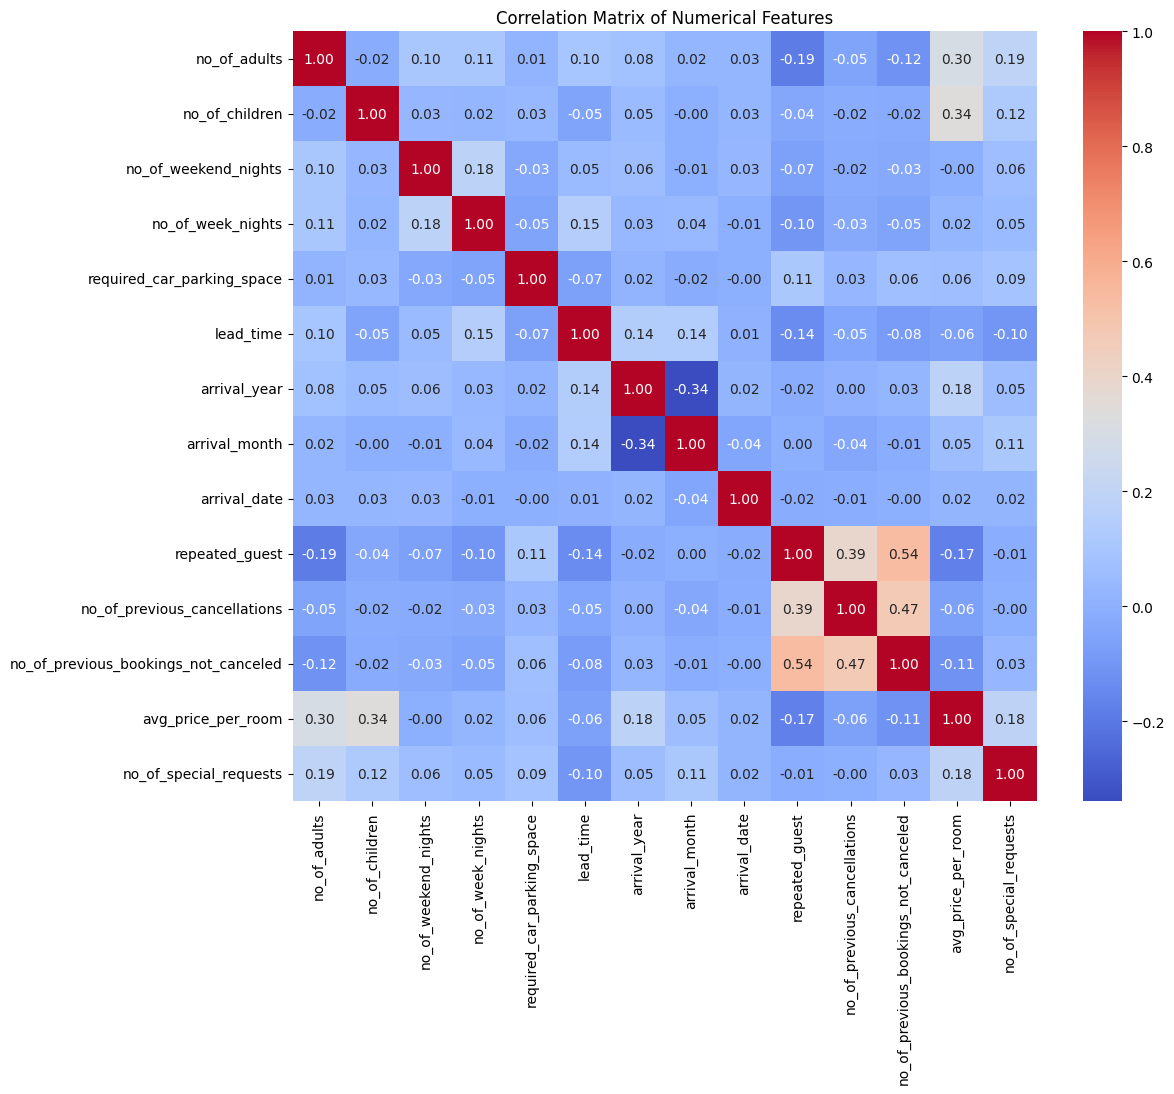

In [5]:
# prompt: Using dataframe df: generate these all plots

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a list of column names for numerical features
numerical_cols = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space',
                  'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations',
                  'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']


# Create histograms for each numerical feature
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Create boxplots for each numerical feature
for col in numerical_cols:
    plt.figure()
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


# Create a list of column names for categorical features
categorical_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']

# Create countplots for each categorical feature
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Correlation matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


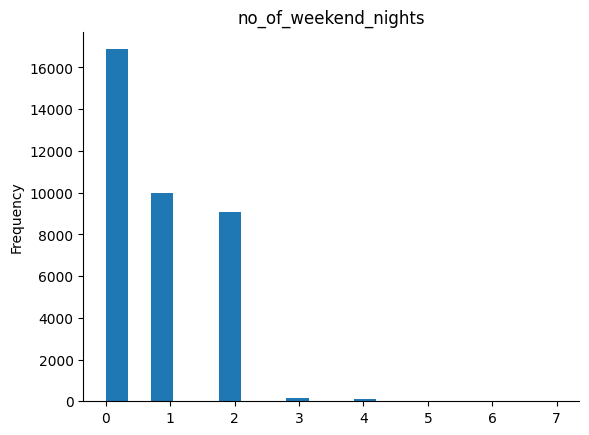

In [6]:
# @title no_of_weekend_nights

from matplotlib import pyplot as plt
df['no_of_weekend_nights'].plot(kind='hist', bins=20, title='no_of_weekend_nights')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [8]:
df = df.drop("Booking_ID",axis=1)

In [9]:
pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 115.6 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=56491011317c49ea4e8c3ab1d5ff6c811556051098043b67d2dec3b461137d99
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


In [10]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)

# نمایش خروجی در یک فایل HTML
profile.to_file("output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
pip install sweetviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 103.1 MB/s eta 0:00:00


In [12]:
import sweetviz as sv

# ایجاد گزارش
report = sv.analyze(df)

# نمایش گزارش در مرورگر
report.show_html("sweetviz_report.html")


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [13]:
df = df.drop_duplicates()

In [20]:
df = df[df['no_of_adults'] != 0]

In [21]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36269,2,2,0,1,Meal Plan 1,0,Room_Type 6,0,2018,10,6,Online,0,0,0,216.00,0,Canceled
36270,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled


In [64]:
# prompt: random forest with grid search on df with label encoder

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Assuming 'df' is your DataFrame and 'booking_status' is your target variable
X = df.drop('booking_status', axis=1)
y = df['booking_status'].values.reshape(-1,1)

# Apply Label Encoding to categorical features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])




In [65]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100,random_state=42)

# # Perform GridSearchCV
# grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_classifier.fit(X_train, y_train)

# # Get the best model
# best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Test",rf_classifier.score(X_test, y_test))
print("Train",rf_classifier.score(X_train,y_train))
print("X,Y",rf_classifier.score(X,y))
# print(f"Best parameters found: {grid_search.best_params_}")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



              precision    recall  f1-score   support

    Canceled       0.79      0.70      0.74      1458
Not_Canceled       0.89      0.93      0.91      3715

    accuracy                           0.86      5173
   macro avg       0.84      0.81      0.83      5173
weighted avg       0.86      0.86      0.86      5173

Test 0.8641020684322444
Train 0.9960371157935434
X,Y 0.9696501063212836


In [67]:
df2=df.copy()
df2.drop(columns=['required_car_parking_space','repeated_guest',"room_type_reserved","arrival_year",
                 "arrival_date"],inplace=True)

In [68]:
X = df2.drop('booking_status', axis=1)
y = df2['booking_status']

# Apply Label Encoding to categorical features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_classifier = RandomForestClassifier(n_estimators=100)

# # Perform GridSearchCV
# grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_classifier.fit(X_train, y_train)

# # Get the best model
# best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Test",rf_classifier.score(X_test, y_test))
print("Train",rf_classifier.score(X_train,y_train))
print("X,Y",rf_classifier.score(X,y))

              precision    recall  f1-score   support

    Canceled       0.79      0.69      0.73      1458
Not_Canceled       0.88      0.93      0.90      3715

    accuracy                           0.86      5173
   macro avg       0.83      0.81      0.82      5173
weighted avg       0.86      0.86      0.86      5173

Test 0.8586893485404987
Train 0.9948289193891359
X,Y 0.9676010052194085


In [41]:
from imblearn.over_sampling import SMOTE, ADASYN
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# Apply Label Encoding to categorical features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
oversample = SMOTE()
over_X, over_y = oversample.fit_resample(X, y)
over_X_train, over_X_test, over_y_train, over_y_test = train_test_split(over_X, over_y, test_size=0.2, stratify=over_y, random_state = 42)

rf_classifier = RandomForestClassifier(n_estimators=100,random_state=83)

# # Perform GridSearchCV
# grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_classifier.fit(over_X_train, over_y_train)

# # Get the best model
# best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
over_y_pred = rf_classifier.predict(over_X_test)

# Evaluate the model
print(classification_report(over_y_test,over_y_pred))
print("Test",rf_classifier.score(over_X_test, over_y_test))
print("Train",rf_classifier.score(over_X_train,over_y_train))
print("X,Y",rf_classifier.score(X,y))

              precision    recall  f1-score   support

    Canceled       0.89      0.89      0.89      3694
Not_Canceled       0.89      0.89      0.89      3693

    accuracy                           0.89      7387
   macro avg       0.89      0.89      0.89      7387
weighted avg       0.89      0.89      0.89      7387

Test 0.8894002978204955
Train 0.9968522592655271
X,Y 0.9690701720471679


In [40]:
ord("S")

83

In [43]:
# prompt: best ml model for df without oversample

from sklearn.ensemble import GradientBoostingClassifier
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# Apply Label Encoding to categorical features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
# ... (Your existing code) ...

# After splitting your data (X_train, X_test, y_train, y_test)

# Initialize the Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the model
gb_classifier.fit(X_train, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Test", gb_classifier.score(X_test, y_test))
print("Train", gb_classifier.score(X_train, y_train))
print("X,Y", gb_classifier.score(X, y))


              precision    recall  f1-score   support

    Canceled       0.79      0.67      0.73      1458
Not_Canceled       0.88      0.93      0.90      3715

    accuracy                           0.86      5173
   macro avg       0.83      0.80      0.81      5173
weighted avg       0.85      0.86      0.85      5173

Test 0.8571428571428571
Train 0.8514884979702301
X,Y 0.8526193698047555


In [60]:
# prompt: model with nn

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming X and y are already defined and preprocessed as in your original code
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# Apply Label Encoding to categorical features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
y=le.fit_transform(y)
# Scale numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Assuming binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Use appropriate loss function for your task
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1) # Adjust epochs and batch_size as needed


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



582/582 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7635 - loss: 0.4755 - val_accuracy: 0.8145 - val_loss: 0.4047
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8235 - loss: 0.3936 - val_accuracy: 0.8300 - val_loss: 0.3807
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8317 - loss: 0.3788 - val_accuracy: 0.8280 - val_loss: 0.3808
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8377 - loss: 0.3670 - val_accuracy: 0.8280 - val_loss: 0.3727
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8400 - loss: 0.3592 - val_accuracy: 0.8309 - val_loss: 0.3672
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8466 - loss: 0.3472 - val_accuracy: 0.8304 - val_loss: 0.3673
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8498 - loss: 0.3408 - val_accuracy: 0.8309 - val_loss: 0.3707
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8473 - loss: 0.3401 - val_accuracy: 0.8338 - val_

In [62]:
# prompt: neural network model with over sampling
# Assuming X and y are already defined and preprocessed as in your original code
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# Apply Label Encoding to categorical features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
y=le.fit_transform(y)
# Scale numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

oversample = SMOTE()
over_X, over_y = oversample.fit_resample(X, y)
over_X_train, over_X_test, over_y_train, over_y_test = train_test_split(over_X, over_y, test_size=0.2, stratify=over_y, random_state = 42)


# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(over_X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Assuming binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Use appropriate loss function for your task
              metrics=['accuracy'])

# Train the model
model.fit(over_X_train, over_y_train, epochs=50, batch_size=32, validation_split=0.1) # Adjust epochs and batch_size as needed


# Evaluate the model
loss, accuracy = model.evaluate(over_X_test, over_y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



831/831 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7622 - loss: 0.4884 - val_accuracy: 0.7922 - val_loss: 0.4283
Epoch 2/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8008 - loss: 0.4114 - val_accuracy: 0.7919 - val_loss: 0.4171
Epoch 3/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8175 - loss: 0.3919 - val_accuracy: 0.8068 - val_loss: 0.4072
Epoch 4/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8282 - loss: 0.3757 - val_accuracy: 0.8176 - val_loss: 0.3968
Epoch 5/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8301 - loss: 0.3705 - val_accuracy: 0.7976 - val_loss: 0.4133
Epoch 6/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8345 - loss: 0.3621 - val_accuracy: 0.8176 - val_loss: 0.3881
Epoch 7/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8359 - loss: 0.3553 - val_accuracy: 0.8156 - val_loss: 0.3934
Epoch 8/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8468 - loss: 0.3399 - val_accuracy: 0.8173 - val_